This notebook will prepare and explore the PassioGo dataset, specifically focusing on merging and inspecting each .csv file to understand their structure, identify relationships, and highlight areas to inform later analysis.

We will begin by importing the necessary libraries and loading in the data through Pandas.

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [17]:
bus_breaks = pd.read_csv("../rutgers_bus_data/bus_breaks.csv")
stops = pd.read_csv("../rutgers_bus_data/stops.csv")
ridership = pd.read_csv("../rutgers_bus_data/ridership.csv")
routes = pd.read_csv("../rutgers_bus_data/routes.csv")
vehicles = pd.read_csv("../rutgers_bus_data/vehicles.csv")

Let's look at the structure of each dataset, checking each of the column names and data types. We will pay attention to columns stored as "objects" that might actually represent numeric or datatime values. It's important to convert timestamps into proper datetime format for future time-based analysis.

In [18]:
datasets = {
    "bus_breaks": bus_breaks,
    "stops": stops,
    "ridership": ridership,
    "routes": routes,
    "vehicles": vehicles
}

for name, df in datasets.items():
    print(f"\n{name} Data Types:")
    print(df.dtypes)


bus_breaks Data Types:
id                  int64
stop_id             int64
time_arrived       object
time_departed      object
break_duration    float64
dtype: object

stops Data Types:
stop_id       int64
name         object
campus       object
shortname    object
dtype: object

ridership Data Types:
bus_id             int64
time               int64
ridership_count    int64
dtype: object

routes Data Types:
route_id         object
stop_sequence    object
dtype: object

vehicles Data Types:
id            int64
name         object
routeId       int64
routeName    object
dtype: object


We see that time_arrived and time_departed are stored as objects. Let's convert them into proper datetime format. 

In [19]:
bus_breaks["time_arrived"] = pd.to_datetime(bus_breaks["time_arrived"])
bus_breaks["time_departed"] = pd.to_datetime(bus_breaks["time_departed"])

Let's start gathering insights from the dataset, beginning with the distribution of bus break times for the sample day given in the csv file. We'll look at how long buses might typically remain at stops and try to extract any insights. We'll bound break_duration at 5 hours for a more realistic operational range.

Text(0, 0.5, 'Frequency')

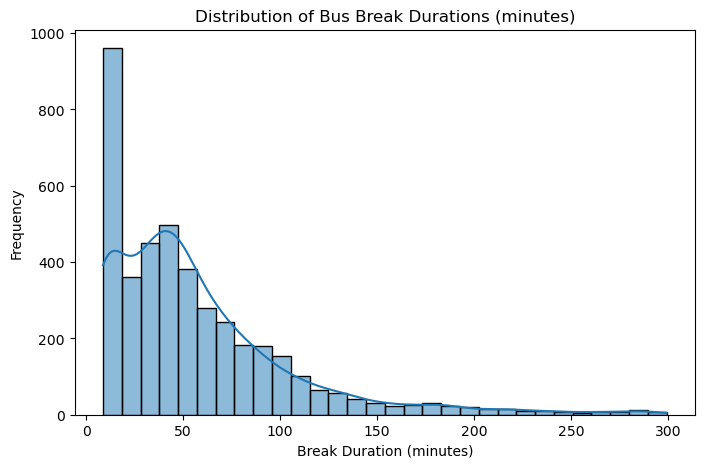

In [20]:
plt.figure(figsize=(8,5))
sns.histplot(bus_breaks[bus_breaks["break_duration"] < 300]["break_duration"],bins=30, kde=True, alpha=0.5)
plt.title("Distribution of Bus Break Durations (minutes)")
plt.xlabel("Break Duration (minutes)")
plt.ylabel("Frequency")

We see that a majority of break times are short, generally being under 50 minutes, with the frequency dropping off as the duration increases. Most buses only stop briefly and a smaller number stay at stops for much longer.

It's important to note that in the dataset's context, break doesn't only mean a driver's personal rest period. It measures how long a bus stays at a stop between its arrival and departure, or effectively the dwell time. It can be impacted by rush-hour crowds, traffic congestion, or events on campus, and not just downtime. 

Since both bus_breaks and stops share stop_id, we can join them to see how dwell times vary across different stops on campus. We'll pair each stop's name and campus with its recorded dwell durations.

In [21]:
bus_stops = bus_breaks.merge(stops, on="stop_id", how="left")

Next, let's visualize the stops with the longest average dwell times.

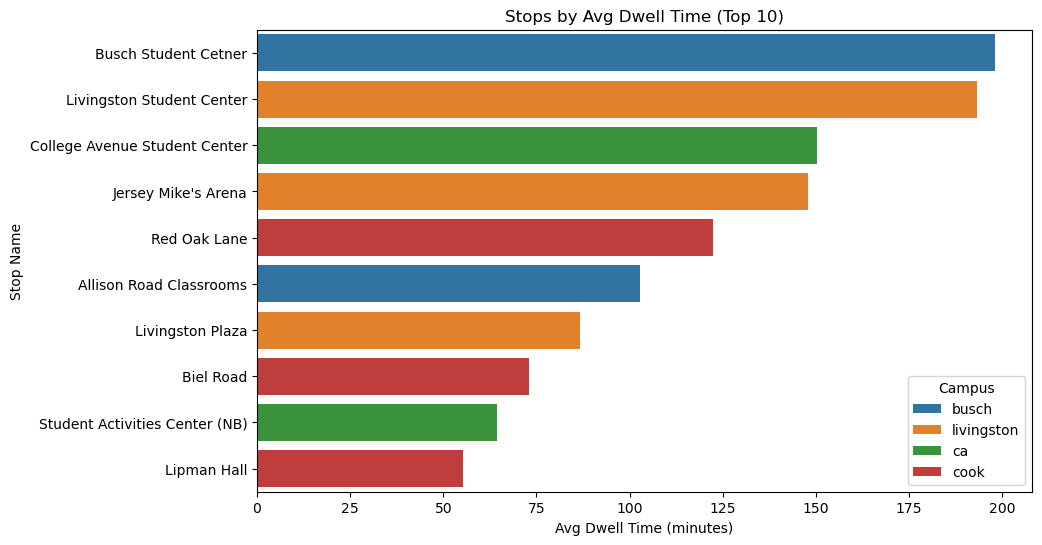

In [22]:
avg_dwell_time = (bus_stops.groupby(["stop_id", "name", "campus"])["break_duration"].mean().reset_index().sort_values("break_duration", ascending=False).head(10))

plt.figure(figsize=(10,6))
sns.barplot(data=avg_dwell_time, y="name", x="break_duration", hue="campus")
plt.title("Stops by Avg Dwell Time (Top 10)")
plt.xlabel("Avg Dwell Time (minutes)")
plt.ylabel("Stop Name")
plt.legend(title="Campus")

We can see that Busch, Livingston, and College Ave Student Centers have the longest average dwell times across all campuses. This lines up with how Rutgers buses operate, with most drivers taking their personal breaks at student centers throughout the day.

Let's try to understand when these longer dwell periods tend to occur by dividing the day into time ranges to see how traffic, passenger volume, and congestion differing throughout the day might impact dwell duration.

In [23]:
bus_stops["hour"] = bus_stops["time_arrived"].dt.hour

def group_time(hour):
    if 6 <= hour < 12:
        return "Morning (6-11 AM)"
    elif 12 <= hour < 16:
        return "Midday (12-3 PM)"
    elif 16 <= hour < 18:
        return "Rush Hour (4-6 PM)"
    elif 18 <= hour < 22:
        return "Evening (6-9 PM)"
    else:
        return "Off Hours"

bus_stops["time_period"] = bus_stops["hour"].apply(group_time)

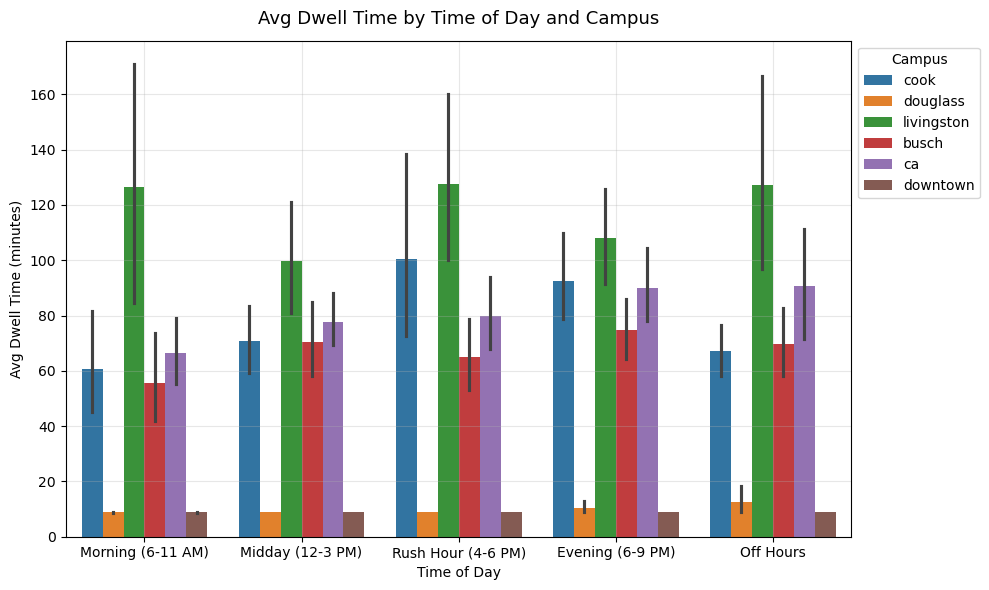

In [24]:
plt.figure(figsize=(10,6))
sns.barplot(data=bus_stops, x="time_period", y="break_duration", hue="campus", estimator="mean", order=["Morning (6-11 AM)", "Midday (12-3 PM)", "Rush Hour (4-6 PM)", "Evening (6-9 PM)", "Off Hours"])
plt.title("Avg Dwell Time by Time of Day and Campus", fontsize=13, pad=12)
plt.xlabel("Time of Day")
plt.ylabel("Avg Dwell Time (minutes)")
plt.legend(title="Campus", loc="upper left", bbox_to_anchor=(1,1))
plt.grid(alpha=0.3)
plt.tight_layout()

We see that at all periods of the day, Livingston has the longest average dwell times across all time periods, especially during rush hour and off hours. Cook also has high dwell times throughout the day, spiking especially during rush hour into the late evenings. Busch and College Ave have relatively high dwell times throughout the day, but stay relatively stable across all time periods. Douglass and Downtown experience much shorter and more consistent dwell durations. 

Earlier, we mentioned that dwell time is likely heavily influenced by traffic congestion and crowds at different periods of the day, but for all campuses besides Livingston and Cook, this doesn’t seem to be the case. Let's take a different approach, like analyzing the number of vehicles passing through each campus to determine whether longer dwell times correspond with a lesser bus frequency.
                                                                                                                                   
We'll first need to extract the lowercase short codes (indicating the bus route) from vehicles['routeName'] in order to join vehicles and routes together.                                                                                                                                    

In [25]:
vehicles["routeName_short"] = (vehicles["routeName"].str.extract(r"([A-Za-z]+)").iloc[:, 0].str.lower())

routes["route_id"] = routes["route_id"].str.lower()

vehicles_routes = vehicles.merge(routes, left_on="routeName_short", right_on="route_id", how="left")

Now that we've merged vehicles and routes, we can determine how many vehicles operate in each route, which will allow us to determine whether those particular routes experience a comparabily high dwell time as a result of less vehicles operating under those routes, or vice versa.

Text(0, 0.5, 'Route ID')

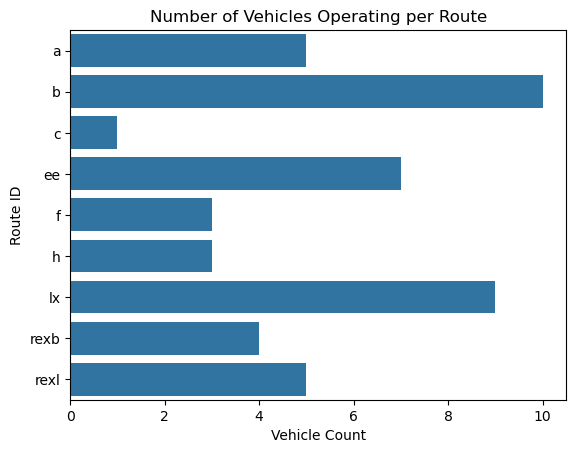

In [26]:
route_vehicle_counts = (vehicles_routes.groupby("route_id")["id"].nunique().reset_index(name="vehicle_count"))

sns.barplot(data=route_vehicle_counts, x="vehicle_count", y="route_id")
plt.title("Number of Vehicles Operating per Route")
plt.xlabel("Vehicle Count")
plt.ylabel("Route ID")

We see that the B and LX routes have the highest number of vehicles operating. These routes are typically the most passenger-dense as they serve as connections between Livingston and Busch/College Ave. In contrast, the C route has the least number of vehicles in route, likely due to it only primarily used by commuters who park on Busch. 

Let's merge bus_breaks.csv with vehicles.csv to attach route info and calculate average dwell time per route.

In [27]:
breaks_with_routes = bus_breaks.merge(vehicles[["id", "routeId", "routeName"]], left_on="id", right_on="id", how="left")

dwell_vs_vehicles = (
    breaks_with_routes.groupby("routeName", as_index=False)["break_duration"].mean().rename(columns={"break_duration": "avg_dwell_duration"})
    .merge(vehicles.groupby("routeName", as_index=False).size().rename(columns={"size": "vehicle_count"}), on="routeName", how="left"
    )
)

dwell_vs_vehicles.head()

,routeName,avg_dwell_duration,vehicle_count
0,A Route,67.003533,5
1,B Route,89.480131,8
2,B/L Loop,105.293931,2
3,C Route,27.250858,1
4,Campus Connect Express,66.843426,1


We'll examine average dwell time along each route to see if there's a measurable relationship between the number of vehicles operating in each route and the amount of time they spend at stops using a scatterplot, with small text offsets to label each route for readability.

Text(0, 0.5, 'Avg Dwell Time (minutes)')

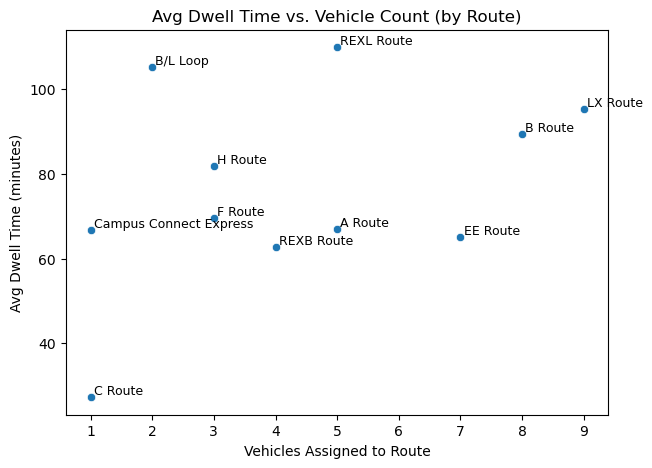

In [28]:
dwell_vs_vehicles = dwell_vs_vehicles.query("vehicle_count > 0 and avg_dwell_duration > 0")

plt.figure(figsize=(7,5))
sns.scatterplot(data=dwell_vs_vehicles, x="vehicle_count", y="avg_dwell_duration")
for _, r in dwell_vs_vehicles.iterrows():
    plt.text(r["vehicle_count"]+0.05, r["avg_dwell_duration"]+0.6, r["routeName"], fontsize=9)
    
plt.title("Avg Dwell Time vs. Vehicle Count (by Route)")
plt.xlabel("Vehicles Assigned to Route")
plt.ylabel("Avg Dwell Time (minutes)")

The results of the graph are similar to our initial guesses: The LX and B routes have the most vehicles and still show some of the highest dwell times, which is likely due to heavy ridership/congestion, and that both routes connect the busiest parts of campus. The C route shows the lowest dwell time, due to it being used by a smaller subset of students. Routes A, REXB, and EE sit in the middle with moderate vehicle counts and dwell time. What's interesting is that REXL experiences significant dwell time, much higher than A despite having the same number of vehicles assigned to the route.

This suggests that fleet size doesn't guarantee efficiency. Vehicle allocation appears to scale with both expected passenger demand and dwell duration, with routes like LX and B having heavier ridership/longer stop times tending to have more buses assigned. Vehicle count is likely a response variable based on expected passenger volume.

**Key Takeaways in Notebook 1**:
- Most dwell times are short, though certain stops, particularly student centers, experienced more prolonged durations.
- Dwell duration patterns vary across time periods and campuses, with Livingston consistently remaining the most congested.
- Routes B and LX show high dwell times, despite having the highest number of vehicles, suggesting that additional fleet size is likely a response to sustained passenger demand rather than a reduction in delays.
- Smaller routes like C show lower dwell times and fewer vehicles, reflecting lighter ridership and less congestion.
- The REXL route experiences the highest dwell time, much higher than A despite having the same number of vehicles.
- We're able to join bus_breaks.csv and stops.csv together through their 'stop_id' key, and vehicles.csv and routes.csv through 'routeId'.

Let's export dwell-related dataframes for later use.

In [29]:
breaks_with_routes.to_csv("breaks_with_routes.csv", index=False)
dwell_vs_vehicles.to_csv("dwell_vs_vehicles.csv", index=False)

In the next notebook, we’ll pivot towards passenger behavior, linking dwell durations with volumes of passengers to identify how crowding and passenger turnover contributes towards longer stops. 